In [29]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [37]:
import os
import sys

current_dir = os.path.dirname(os.path.abspath('.'))
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

Let's define our volume using helper function `get_layers`

In [38]:
from tomopt.volume import Volume
from detector_config import get_layers

We start with both groups of panels tightly stacked on either side of the VOI.

In [39]:
volume = Volume(get_layers(panel_z_spacing=0.01, n_panels=3, init_gap=0., init_res=5000, smooth=0.01))


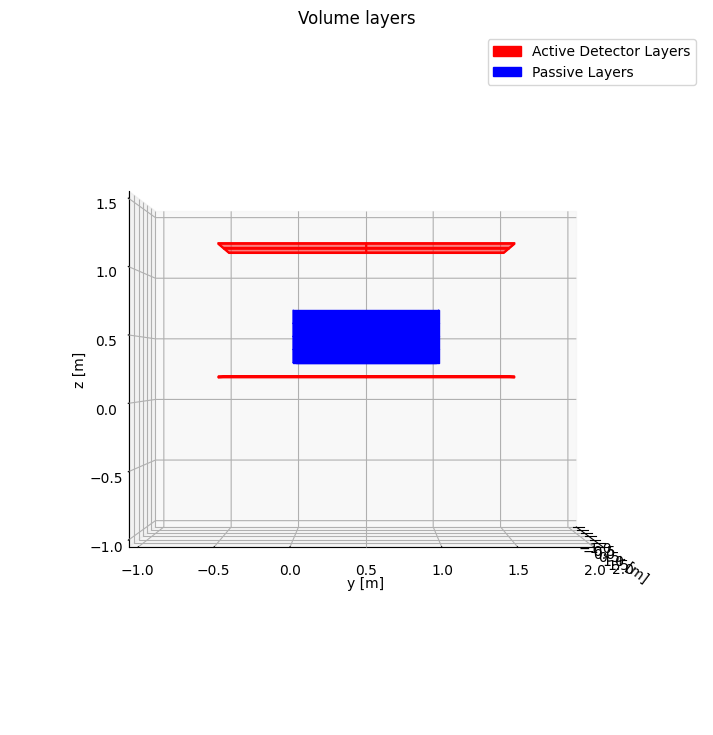

In [40]:
from utils import draw

draw(volume, xlim=[-1., 2.], ylim=[-1., 2.], zlim=[-1., 1.5], rotate = 0)

Next we define the wrapper object, tailored for a hypothesis test loss function. The loss instance is also defined as an argument when instantiating the wrapper.

In [ ]:
from functools import partial
import torch
from co_design_optimization.wrapper import CoDesignVolumeWrapper
from co_design_optimization.utility_loss import HypothesisTestLoss

wrapper = CoDesignVolumeWrapper(
    volume,
    # xy_pos_opt=partial(torch.optim.SGD, lr=0),
    # xy_span_opt=partial(torch.optim.SGD, lr=0),
    # z_pos_opt=partial(torch.optim.SGD, lr=1e-3),
    # gap_opt=partial(torch.optim.SGD, lr=0),
    # sigma_soft_opt=partial(torch.optim.SGD, lr=1e-3),
    xy_pos_opt    = partial(torch.optim.AdamW, lr=0, betas=(0.9, 0.999)),
    xy_span_opt   = partial(torch.optim.AdamW, lr=0, betas=(0.9, 0.999)),
    z_pos_opt     = partial(torch.optim.AdamW, lr=1e-2, weight_decay=0),
    gap_opt       = partial(torch.optim.AdamW, lr=0, betas=(0.9, 0.999)),
    #log_sigma_sw_opt= partial(torch.optim.AdamW, lr=1e-2, weight_decay=0),

    loss_func = HypothesisTestLossInner(
        alpha=0.05,
        beta=200.0,
        #tau_q= 0.0001,
        tau_detect=20,
        debug=True,
        init_sigma_sw=0.008,
        tau_p=0.1,
        n_bins = 50,
    ),

)

Below, we build the passive volumes belonging to two sets: null volumes defined as a block of a homogeneous background material, and signal volumes containing in addition a high-Z target at a fixed position inside the block.

In [42]:
from torch import Tensor
from tomopt.core import X0
from tomopt.optimisation.data import PassiveYielder

bkg_mat = 'aluminium'
block_mat = 'uranium'

def cubes_rad_length(*, z: float, lw: Tensor, size: float, signal: bool = False) -> Tensor:
    rad_length = torch.ones(list((lw / size).long())) * X0[bkg_mat]
    grid = torch.zeros_like(rad_length)

    cube_size = 1
    offset = 2
    if signal and (z > 0.3 and z < 0.5):
        grid[-offset - cube_size : -offset, offset : offset + cube_size] = X0[block_mat]
        rad_length[grid.bool()] = grid[grid.bool()]

    return rad_length

n_samples = 50
# Create passive material for the volume
passives = PassiveYielder([lambda **kwargs: cubes_rad_length(**kwargs, signal=False)]*n_samples + [lambda **kwargs: cubes_rad_length(**kwargs, signal=True)]*n_samples 
                           #+[lambda **kwargs: cubes_rad_length(**kwargs, signal=False)]*n_samples + [lambda **kwargs: cubes_rad_length(**kwargs, signal=True)]*n_samples
                           #+[lambda **kwargs: cubes_rad_length(**kwargs, signal=False)]*n_samples + [lambda **kwargs: cubes_rad_length(**kwargs, signal=True)]*n_samples
                           #+ [lambda **kwargs: cubes_rad_length(**kwargs, signal=False)]*n_samples + [lambda **kwargs: cubes_rad_length(**kwargs, signal=True)]*n_samples
                          ,shuffle=False)

Now let's run the optimization with the `fit()` method of the wrapper. <br>
The main callbacks that are essential fot the this use case of hypothesis testing are in `HypothesisTestCallback`. This class is used to feed the loss object with the scattering samples obtained while scanning the passive volumes of each background/signal set. <br>
Callbacks can be used to set learning rate schedulers (`OneCycle` or `ReduceLROnPlateauCallback`). `ReduceLRResponsible` reduces does ReduceLROnPlateau of only the parameters of highest gradient impact. <br>
Also, `PlotLoss` callback shows the a live monitoring of the loss. <br>
A learning rate warm-up phase is usually done with `OptConfig`.

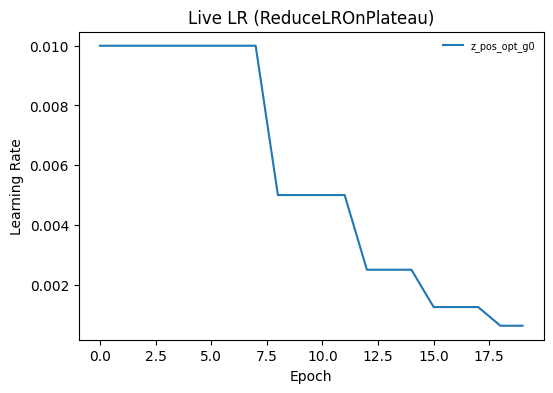

[0.9324909448623657, 0.9140343070030212, 0.8351069688796997, 0.9964187145233154, 0.8423898220062256, 0.8046452403068542, 0.9080440402030945, 0.8278207182884216, 0.8757555484771729, 0.5356652736663818, 0.6933436393737793, 0.7090349793434143, 0.8129885792732239, 0.7023324966430664, 0.8616673946380615, 0.7216558456420898, 0.7348245978355408, 0.7625059485435486, 0.6823328733444214, 0.4840180277824402]


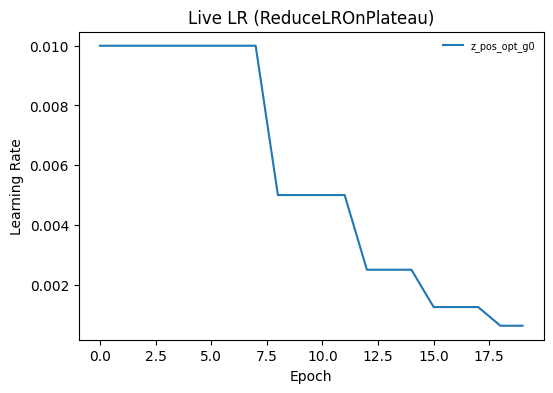

In [43]:
from tomopt.optimisation import OptConfig, MuonResampler
from callbacks import SigmoidPanelSmoothnessSchedule
from co_design_optimization.callbacks import PlotLoss, ClipSigmaSoftGrad, HypothesisTestCallback, LiveLrPlotCallback, OneCycle, ReduceLROnPlateauCallback, ReduceLRResponsible

_ = wrapper.fit(n_epochs=20,  # Run for 10 epochs (5+5 are warmup epochs)""
                passive_bs=2*n_samples,  # Update every passive volumes (we only have one)
                n_mu_per_volume=3000,  # Use 1000 per passive volume
                mu_bs=1000,  # Run the 1000 muons per volume in 10 batchesnomorenans' of 100 muons (quicker than a single batch of 1000)
                trn_passives=passives,
                val_passives=None, #passives,  # Evaluate on the training data
                cbs=[ HypothesisTestCallback(),
                    #OptConfig(n_warmup=2, rates={'xy_pos_opt':0.0, 'z_pos_opt':0.01, 'xy_span_opt':0.0, 'gap_opt':0.0, 'log_sigma_sw_opt':0.01}),
                    MuonResampler(),
                    #OneCycle('z_pos_opt', init_lr= 0.001, mid_lr=0.01, final_lr= 0.001, warmup_length=5),
                    #OneCycle('sigma_soft_opt', init_lr= 0.01, mid_lr=0.02, final_lr= 0.0001, warmup_length=5),
                    #SigmoidPanelSmoothnessSchedule((0.1, 0.001))
                    ReduceLROnPlateauCallback(),
                    #ReduceLRResponsible(patience=5),
                    PlotLoss(save_path='plots/loss'),
                    ClipSigmaSoftGrad()
                    ]) 

Plotting only training loss:

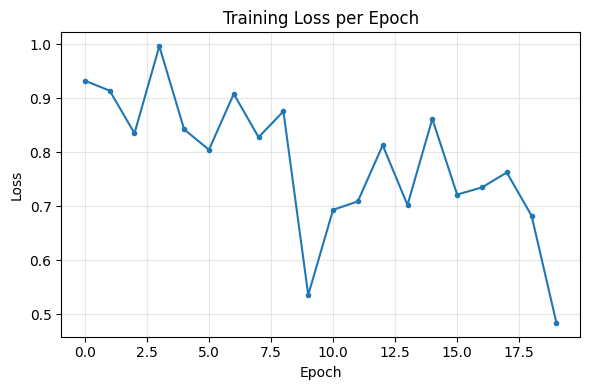

In [44]:
wrapper.plot_train_loss()


Plotting hardware angular resolution across epochs:

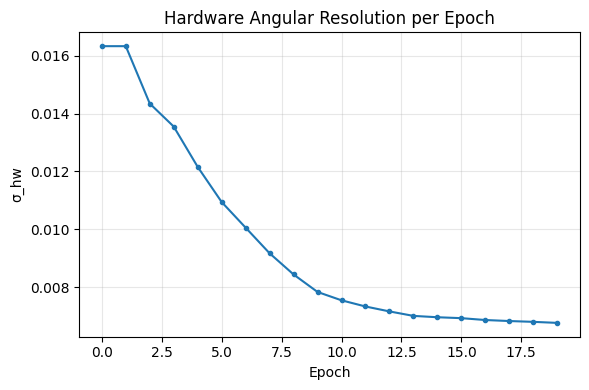

In [45]:
wrapper.plot_sigma_hw()



Plotting the software smoothing parameter (in log scale)

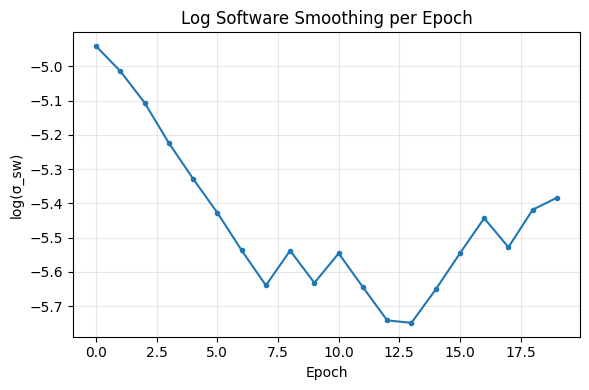

In [46]:
wrapper.plot_log_sigma_sw()

Ploting 2D utility landscape

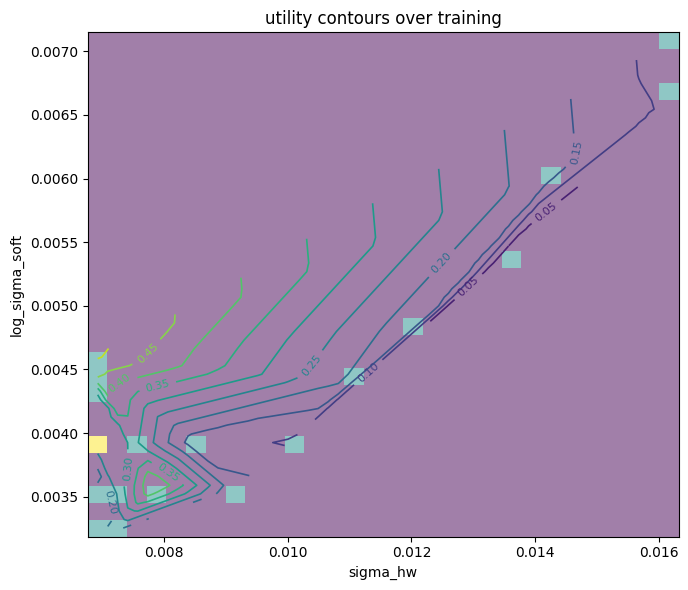

In [47]:
import matplotlib.pyplot as plt
import numpy as np

sig_hw   = np.array(wrapper.history['sigma_hw'])
sig_soft = np.exp(np.array(wrapper.history['log_sigma_sw']))
power     = 1-np.array(wrapper.history['train_loss'])

# Grid for contour
nx = ny = 60
xg = np.linspace(sig_hw.min(), sig_hw.max(), nx)
yg = np.linspace(sig_soft.min(), sig_soft.max(), ny)
X, Y = np.meshgrid(xg, yg)

# Interpolate loss onto grid (very light nearest-neighbour)
from scipy.interpolate import griddata
Z = griddata(
    points=np.column_stack([sig_hw, sig_soft]),
    values=power,
    xi=(X, Y),
    method="linear"
)

plt.figure(figsize=(7,6))

# background histogram
plt.hist2d(sig_hw, sig_soft, bins=30, cmap="viridis", alpha=0.5)

# loss contours
cs = plt.contour(X, Y, Z, levels=10, linewidths=1.2)
plt.clabel(cs, inline=True, fontsize=8)


plt.xlabel("sigma_hw")
plt.ylabel("log_sigma_soft")
plt.title("utility contours over training")
plt.tight_layout()
plt.show()


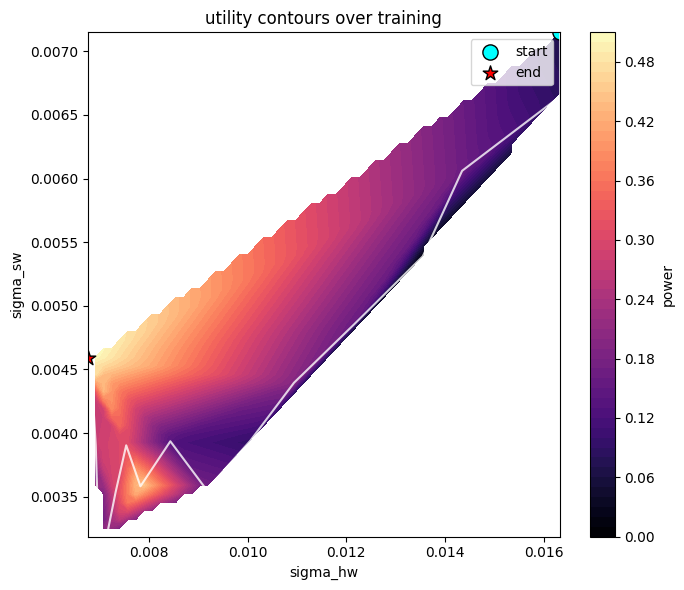

In [56]:

sig_hw   = np.array(wrapper.history['sigma_hw'])
sig_soft = np.exp(np.array(wrapper.history['log_sigma_sw']))
power     = 1-np.array(wrapper.history['train_loss'])

# Grid for contour
nx = ny = 60
xg = np.linspace(sig_hw.min(), sig_hw.max(), nx)
yg = np.linspace(sig_soft.min(), sig_soft.max(), ny)
X, Y = np.meshgrid(xg, yg)

# Interpolate loss onto grid (very light nearest-neighbour)
from scipy.interpolate import griddata
Z = griddata(
    points=np.column_stack([sig_hw, sig_soft]),
    values=power,
    xi=(X, Y),
    method="linear"
)
plt.figure(figsize=(7,6))

# background histogram
#plt.hist2d(sig_hw, sig_soft, bins=30, cmap="viridis", alpha=0.4)

# continuous filled contour
cs = plt.contourf(X, Y, Z, levels=50, cmap="magma")  # more levels = smoother

# start / end points
start_hw, start_sw = sig_hw[0], sig_soft[0]
end_hw, end_sw     = sig_hw[-1], sig_soft[-1]

# plot them
plt.scatter(start_hw, start_sw, c="cyan", s=120, marker="o", label="start", edgecolors="k")
plt.scatter(end_hw, end_sw, c="red",  s=120, marker="*", label="end",   edgecolors="k")

# optional trajectory
plt.plot(sig_hw, sig_soft, color="white", lw=1.5, alpha=0.8)

plt.legend()


# colorbar
cbar = plt.colorbar(cs)
cbar.set_label("power")

plt.xlabel("sigma_hw")
plt.ylabel("sigma_sw")
plt.title("utility contours over training")
plt.tight_layout()
plt.show()




Plotting final detector configuration

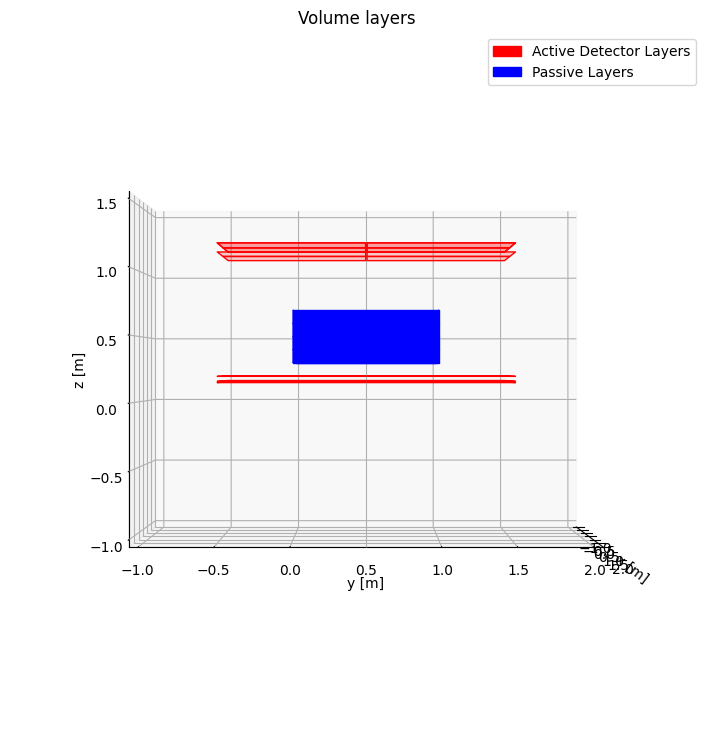

In [48]:
draw(volume, xlim=[-1., 2.], ylim=[-1., 2.], zlim=[-1., 1.5], rotate = 0)

In [51]:
wrapper.volume.get_detectors()[0].panels[2].z

Parameter containing:
tensor([1.1313], requires_grad=True)